# 本ipynb批量导出yihan数据集的图片

In [ ]:
%load_ext autoreload

# 查看当前Python解释器的路径(q请确保指向目标虚拟环境而非默认环境)
import sys
print(sys.executable)

################################################################
# 请检查版本号以确定更新到最新版本，截至20250131，版本更新至0.3.8.5
# 实践表明可能会发生假更新, 故需要确定版本号
################################################################
import tianmoucv 


/home/yuguo/anaconda3/envs/env_tianmouc_mocap/bin/python3.10
TianMouCV™ version: 0.4.1.1 , via Y. Lin  see DEVLOG.md
试验功能:TianMouCV将限制单进程中opencv与pytorch默认的线程上限为CPU总核心数的1/4(<=32): 32/256


# 引入必要的库

In [ ]:
%autoreload

import cv2
import math
import os
import shutil
import sys
import time
import torch
import matplotlib.pyplot   as plt
import numpy               as np
import torch.nn.functional as F

from tianmoucv.data import TianmoucDataReader # tmdat数据读取器
from tianmoucv.isp  import SD2XY              # 将斜向差分改为XY方向差分
from tianmoucv.data import cone_tmdat_to_npy, rod_tmdat_to_npy # 单独读取某通道数据(并不完善, 仅用于底层调试)
from tianmoucv.data.denoise_utils import denoise_defualt_args  # yuxiang的去噪算法

sys.path.append('../../src/basic')
from basic import images_to_video # 将图片列表导出并保存为视频
from basic import viz_diffTensor2img, overlay_rgb_diff # 时空差分数据可视化
from basic import extract_COP_images, save_COP_images  # 根据关键帧提取并保存COP图片

# 准备数据

In [ ]:
train = '/home/yuguo/data_yuguo/dataset/tianmoucReconDataset_0701new/train/'
val   = '/home/yuguo/data_yuguo/dataset/tianmoucReconDataset_0701new/test/'
train_list = os.listdir(train)
val_list   = os.listdir(val)
train_data = [train + e for e in train_list]
val_data   = [val + e for e in val_list]

key_list = []

for train_val_data in [train_data, val_data]:
    for sampleset in train_val_data:
        count_e = 0
        for e in os.listdir(sampleset):
            if e == '.ipynb_checkpoints': continue
            count_e = count_e + 1
            print(e,end=" ")
            key_list.append(e)
        print('\n---->', sampleset, '有：', count_e, '个样本.\n')

dataPath = val_data + train_data

NM_indoor_slefie_2 NM_train_exam_full1 NM_train_running_man_6 NM_train_exam_full4 NM_train_exam_fan2 NM_indoor_office_3 NM_train_driving14 NM_indoor_slefie_1 NM_train_indoor_dog1 NM_train_indoor_dog4 NM_train_cross3 NM_indoor_office_4 NM_indoor_office_1 NM_traffic9 NM_outdoor_cross_9 NM_train_driving9 NM_train_driving6 NM_traffic3 NM_traffic11 NM_train_driving5 NM_train_driving13 NM_train_driving4 NM_outdoor_bridge_1 NM_train_exam_fan5 NM_outdoor_bridge_2 NM_traffic10 NM_traffic1 NM_train_driving10 NM_traffic2 NM_indoor_office_2 NM_outdoor_cross_7 NM_traffic7 NM_NM_flag_1 NM_train_cross2 NM_traffic14 NM_outdoor_cross_11 NM_traffic_nohdr_16 NM_train_exam_fan1 NM_outdoor_cross_12 NM_train_exam_fan3 NM_traffic6 NM_train_driving3 NM_train_driving2 NM_outdoor_cross_1 NM_outdoor_bz_1 NM_train_driving8 NM_train_driving11 NM_outdoor_cross_3 NM_people1 NM_train_exam_full2 NM_train_driving7 NM_train_running_man_7 NM_traffic_nohdr_15 NM_train_running_man_5 NM_outdoor_4huan NM_outdoor_cross_8 NM_t

# 单目数据处理: 预览, 导出图片帧, 导出视频(待调试)\

In [ ]:
%autoreload

# dataPath = ['/home/yuguo/data_yuguo/dataset/dataset_Tianmouc_MoCap/MaskTest_20251213_snow_outdoors_singleCAM/test_snow_20251213']
# !ls          /home/yuguo/data_yuguo/dataset/dataset_Tianmouc_MoCap/MaskTest_20251213_snow_outdoors_singleCAM/test_snow_20251213
# key_list = []
# key_list.append('002')

en_preview    = 0  # 预览
en_save_img   = 1  # 将数据保存为图片
en_save_video = 0  # 将数据导出为视频

en_portrait   = 0  # 相机竖直拍摄, 图片需要旋转90°
en_overlay    = 0  # AOP可视化时叠加COP数据

for key in key_list:
    
    dataset_list = TianmoucDataReader(dataPath, N = 1, matchkey = key, camera_idx = 0, strict=False)

    ######## 设置数据保存路径
    if en_save_img: 
        # 批量处理, 在主目录平行建立simple_image存储图像，一般用于一次性需要查看许多视频的图片的时候
        sub_directory = os.path.join(dataPath[0], 'simple_image_total') # 与下一行代码二选一
        # 单段处理, 在对应的cone和rod所在的目录平行建立simple_image存储图像
        # sub_directory = os.path.join(dataPath[0], key)                  # 与上一行代码二选一
        save_dir_key = "simple_image_"+key
        save_dir_img = os.path.join(sub_directory, save_dir_key)
        if not os.path.exists(save_dir_img):
            os.makedirs(save_dir_img, exist_ok=True) # 新建目录
            print(save_dir_img+' is created.')
    if en_save_video: 
        # 单段处理, 在对应的cone和rod所在的目录平行建立simple_video存储图像
        sub_directory  = os.path.join(dataPath[0], key)
        save_dir_key   = "simple_video"
        save_dir_video = os.path.join(sub_directory, save_dir_key)
        if not os.path.exists(save_dir_video):
            os.makedirs(save_dir_video, exist_ok=True) # 新建目录
            print(save_dir_video+' is created.')

    # 仅处理部分COP数据
    # index_COP_start = 0 # COP起始帧(包含该帧)
    # index_COP_end   = len(dataset_list) # COP结束帧(包含该帧)
    # index_COP_step  = 100 # 间隔N个COP帧选1帧
    # index_COP_list  = range(index_COP_start, index_COP_end+1, index_COP_step)
    index_COP_list  = [int(len(dataset_list)/2)]

    if en_save_video: img_list = [] # 用于保存图片序列
    for index_COP in index_COP_list:
        sample  = dataset_list[index_COP]
        #### 处理COP数据
        rgb     = sample['F0']
        rgb     = torch.flip(rgb, [1])        # 镜像翻转
        rgb     = (rgb * 255).to(torch.uint8) # 转换为255
        rgb_out = cv2.UMat(rgb.numpy())       # 注意，带out的图片用于添加文字，且数据类型为uint8
        text    = "COP index: {}".format(index_COP) # 为COP添加文字注释
        cv2.putText(rgb_out, text,  (20, 50),   cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 4, cv2.LINE_AA)
        cv2.putText(rgb_out, 'COP', (520, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 4, cv2.LINE_AA)

        #### 读取AOP数据
        tsdiff  = sample['tsdiff']        # 320×640分辨率
        rawdiff = sample['rawDiff']/255.0 # 160×160分辨率，用于斜向差分转XY
        index_AOP_list = [0]                          # 仅选取第1帧
        # index_AOP_list = range(rawdiff.shape[1]-1)    # 选取所有帧
        # index_AOP_list = range(0, rawdiff.shape[1]-1, 5) # 间隔N个AOP帧选1帧
        for index_AOP in index_AOP_list:
            # 时间差分
            TD     = tsdiff[0, index_AOP,...]
            TD     = torch.flip(TD, [1]) # 镜像翻转
            TD_out = viz_diffTensor2img(TD, TH = 5, FF = 4096) # 时空差分数据可视化
            if en_overlay:
                TD_out = overlay_rgb_diff(rgb, TD_out)
            TD_out = cv2.UMat(TD_out.numpy())
            text   = "AOP index: {}".format(index_AOP)
            cv2.putText(TD_out,  text,  (20, 50),   cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(TD_out,  'TD',  (520, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 4, cv2.LINE_AA)
            
            # 空间差分
            SD = rawdiff[1:,index_AOP,...].permute(1,2,0)
            SDx, SDy = SD2XY(SD)
            SDx = torch.flip(SDx, [1]) # 镜像翻转
            SDy = torch.flip(SDy, [1]) # 镜像翻转
            SDx = SDx.unsqueeze(0).unsqueeze(0) # 增加维度用于插值
            SDy = SDy.unsqueeze(0).unsqueeze(0) # 增加维度用于插值
            SDx_640x320 = F.interpolate(SDx, size = (320, 640), mode = 'bilinear') # 插值使分辨率与COP一致
            SDy_640x320 = F.interpolate(SDy, size = (320, 640), mode = 'bilinear') # 插值使分辨率与COP一致
            SDx_640x320 = SDx_640x320.squeeze(0).squeeze(0) # 消除多余维度
            SDy_640x320 = SDy_640x320.squeeze(0).squeeze(0) # 消除多余维度
            SDx_out = viz_diffTensor2img(SDx_640x320, TH = 1, FF = 8000) # 时空差分数据可视化
            SDy_out = viz_diffTensor2img(SDy_640x320, TH = 1, FF = 8000) # 时空差分数据可视化
            if en_overlay:
                SDx_out = overlay_rgb_diff(rgb, SDx_out)
                SDy_out = overlay_rgb_diff(rgb, SDy_out)
            SDx_out = cv2.UMat(SDx_out.numpy())
            SDy_out = cv2.UMat(SDy_out.numpy())
            cv2.putText(SDx_out, text,  (20, 50),   cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(SDx_out, 'SDx', (520, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(SDy_out, text,  (20, 50),   cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(SDy_out, 'SDy', (520, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 4, cv2.LINE_AA)

            result_cat1  = cv2.hconcat([rgb_out,     TD_out] )
            result_cat2  = cv2.hconcat([SDx_out,     SDy_out])
            result_final = cv2.vconcat([result_cat1, result_cat2])

            result_final = rgb_out
            
            if en_portrait: # 相机竖直拍摄, 修改通道间拼接顺序
                # 可选参数: cv2.ROTATE_90_CLOCKWISE顺时针90度, cv2.ROTATE_180旋转180度, cv2.ROTATE_90_COUNTERCLOCKWISE逆时针90度
                rgb_out_rotate = cv2.rotate(rgb_out, cv2.ROTATE_90_CLOCKWISE)
                TD_out_rotate  = cv2.rotate(TD_out,  cv2.ROTATE_90_CLOCKWISE)
                SDx_out_rotate = cv2.rotate(SDx_out, cv2.ROTATE_90_CLOCKWISE)
                SDy_out_rotate = cv2.rotate(SDy_out, cv2.ROTATE_90_CLOCKWISE)
                result_final = cv2.hconcat([rgb_out_rotate, TD_out_rotate, SDx_out_rotate, SDy_out_rotate]) # 修改通道间拼接顺序

            if en_preview: # 预览图像
                plt.figure(figsize=(10, 5)) 
                plt.imshow(result_final.get()) # plt要求颜色通道为RGB
                plt.show()

            if en_save_img: # 保存图像 
                result_final      = cv2.cvtColor(result_final, cv2.COLOR_RGB2BGR) # cv2要求颜色通道为BGR
                index_COP_str     = '{:04d}'.format(index_COP)
                save_dir_img_file = save_dir_img+'/'+key+'_COP'+index_COP_str+'_AOP'+str(index_AOP)+'.png'
                cv2.imwrite(save_dir_img_file, result_final)

            if en_save_video: # 保存视频
                result_final = cv2.cvtColor(result_final, cv2.COLOR_RGB2BGR) # 视频导出要求颜色通道为BGR 
                img_list.append(result_final.get())
        
        # 实时打印代码执行进展
        if index_COP % 5 == 0:
            print('process: '+key+'; COP_index: '+str(index_COP)+'/'+str(len(dataset_list))+'.')
            
    if en_save_video: # 保存视频
        images_to_video(img_list,save_dir_video+'/'+key+'_RGB_video_Kernel_2.mp4', fps = 30)
        # images_to_video(img_list, './'+key+'_demo_64_68.mp4', fps = 30)


print('done')

[tianmoucv Datareader Warning]TXT Description File Missing, set rodfilepersample == 25 as default
[tianmoucv Datareader FULL] NM_indoor_slefie_2@home/yuguo/data_yuguo/dataset/tianmoucReconDataset_0701new/train/normal extracted length: 66
[tianmoucv Datareader] NM_indoor_slefie_2@h ..., --- containing [RGB,NxTSD] sample: 66  packs
/home/yuguo/data_yuguo/dataset/tianmoucReconDataset_0701new/test/normal/simple_image_total/simple_image_NM_indoor_slefie_2 is created.
[tianmoucv Datareader FULL] NM_train_exam_full1@home/yuguo/data_yuguo/dataset/tianmoucReconDataset_0701new/train/normal extracted length: 150
[tianmoucv Datareader] NM_train_exam_full1@ ..., --- containing [RGB,NxTSD] sample: 150  packs
/home/yuguo/data_yuguo/dataset/tianmoucReconDataset_0701new/test/normal/simple_image_total/simple_image_NM_train_exam_full1 is created.
process: NM_train_exam_full1; COP_index: 75/150.
[tianmoucv Datareader FULL] NM_train_running_man_6@home/yuguo/data_yuguo/dataset/tianmoucReconDataset_0701new/t

# 先定义深度映射函数和可视化函数

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# depth_raw的单位是毫米，分辨率是640*360
def map_depth_to_regular(depth_raw, K_reg, K_rgbd, T_rgbd2reg):
    depth_mm = depth_raw.copy()
    depth_cropped = depth_mm[20:340, :]  # 取中间320行
    h, w = depth_cropped.shape
    aligned_depth = np.full((h, w), 65535.0, dtype=np.float32)

    # 2. 筛选有效深度 (0 < depth < 10000mm)
    mask_valid = (depth_cropped > 0) & (depth_cropped < 10000)

    # 3. 反投影：RGBD 2D像素 -> RGBD相机坐标系 3D点
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    u_v = u[mask_valid]
    v_v = v[mask_valid]
    z_v = depth_cropped[mask_valid]
    # 根据内参公式: x = (u-cx)*z/fx, y = (v-cy)*z/fy
    x_rgbd = (u_v - K_rgbd[0, 2]) * z_v / K_rgbd[0, 0]
    y_rgbd = (v_v - K_rgbd[1, 2]) * z_v / K_rgbd[1, 1]
    p_rgbd = np.vstack((x_rgbd, y_rgbd, z_v, np.ones_like(z_v)))

    # 4. 坐标系变换：RGBD 3D -> 常规相机 3D
    p_reg = T_rgbd2reg @ p_rgbd
    x_r, y_r, z_r = p_reg[0], p_reg[1], p_reg[2]

    # 5. 投影：常规相机 3D -> 常规相机 2D 像素
    # 过滤掉 z <= 0 的点防止除零错误
    mask_front = z_r > 0
    u_reg = (K_reg[0, 0] * x_r[mask_front] / z_r[mask_front] + K_reg[0, 2])
    v_reg = (K_reg[1, 1] * y_r[mask_front] / z_r[mask_front] + K_reg[1, 2])
    z_final = z_r[mask_front]

    # 6. 边界检查与赋值 (Z-buffer) # 取整得到像素索引
    u_idx = np.round(u_reg).astype(int)
    v_idx = np.round(v_reg).astype(int)
    in_view = (u_idx >= 0) & (u_idx < w) & (v_idx >= 0) & (v_idx < h)
    u_idx, v_idx, z_final = u_idx[in_view], v_idx[in_view], z_final[in_view]

    # 排序：从远到近，确保赋值时近处的覆盖远处的
    sort_idx = np.argsort(z_final)[::-1]
    aligned_depth[v_idx[sort_idx], u_idx[sort_idx]] = z_final[sort_idx]

    return aligned_depth

def visualize_depth(depth_map, title=-1):
    """
    可视化深度图像，无效值(65535)显示为黑色
    """
    vis_depth = depth_map.copy()
    mask_invalid = (vis_depth >= 65535) | (vis_depth <= 0)
    
    # 归一化用于显示
    valid_max = vis_depth[~mask_invalid].max() if np.any(~mask_invalid) else 10000
    vis_depth[mask_invalid] = 0

    if title == -1:
        normalized_depth = np.clip(vis_depth, 0, valid_max) / valid_max  # 先裁剪再归一化
        rgba_map = cm.jet(normalized_depth)
        rgb_image = (rgba_map[..., :3] * 255).astype(np.uint8)
        return rgb_image
    else:
        plt.imshow(vis_depth, cmap='jet', vmin=0, vmax=valid_max)
        plt.title(title)
        plt.colorbar(label='mm')
        return



# --- 1. 参数定义 ---
K_reg = np.array([
    [421.131983348472, 0, 352.526338482358],
    [0, 418.398715836072, 138.004138954699],
    [0, 0, 1] ])

# 注意：此内参对应 640*320 图像
K_rgbd = np.array([
    [303.767503286006, 0, 328.886163626516],
    [0, 301.119954716650, 162.449746775961],
    [0, 0, 1] ])

T_rgbd2reg = np.array([
    [0.999656547344703, 0.0141026445686917, -0.0220885211600205, -12.8872656367451],
    [-0.0140385343094630, 0.999896788513195, 0.00305481185051443, 78.7208294518088],
    [0.0221293222966623, -0.00274367220512268, 0.999751351765788, 6.31527761425106],
    [0, 0, 0, 1] ])
T_rgbd2reg = np.linalg.inv(T_rgbd2reg) # ! 我这边的这个需要反过来，因为有些bug

# 用于RGBD和TMC空间对齐，提取COP图像

In [ ]:
%autoreload

dataPath = ['/data6/xiangru/for_lyh/depth_evaluation/tianmou_data']
!ls          /data6/xiangru/for_lyh/depth_evaluation/tianmou_data
key_list = []
key_list.append('static_1')

en_save_img    = 0 # 将数据保存为图片
en_save_video  = 0 # 将数据保存为视频

for key in key_list:
    
    dataset_list = TianmoucDataReader(dataPath, N = 1, matchkey = key, camera_idx = 0, strict=False)

    ######## 设置数据保存路径
    if en_save_img: 
        save_dir_img_tmc  = '/home/yuguo/data_yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_preexp/STEREO_CALIB/CAM0_TMC'
        save_dir_img_rgbd = '/home/yuguo/data_yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_preexp/STEREO_CALIB/CAM1_RGBD'
        if not os.path.exists(save_dir_img_tmc):
            os.makedirs(save_dir_img_tmc, exist_ok = True) # 新建目录
            print(save_dir_img_tmc + ' is created.')        
        if not os.path.exists(save_dir_img_rgbd):
            os.makedirs(save_dir_img_rgbd, exist_ok = True) # 新建目录
            print(save_dir_img_rgbd + ' is created.')

    # 仅处理部分COP数据
    index_COP_start = 500 # COP起始帧(包含该帧)
    index_COP_end   = 5000 # COP结束帧(包含该帧)
    index_COP_step  = 10 # 间隔N个COP帧选1帧
    index_COP_list  = range(index_COP_start, index_COP_end+1, index_COP_step)
    # index_COP_list  = [1000]

    count_saveimg = 0

    if en_save_video == 1: img_list = []
    for index_COP in index_COP_list:
        sample  = dataset_list[index_COP]
        rgb     = sample['F0']
        rgb     = torch.flip(rgb, [1])        # 镜像翻转
        rgb     = (rgb * 255).to(torch.uint8) # 转换为255
        rgb_out = cv2.UMat(rgb.numpy())       # 注意，带out的图片用于添加文字，且数据类型为uint8
        result_final = cv2.cvtColor(rgb_out, cv2.COLOR_RGB2BGR) # cv2要求颜色通道为BGR
        count_saveimg_str = '{:04d}'.format(count_saveimg)
        save_dir_img_file = save_dir_img_tmc + '/' + count_saveimg_str + '.png'
        if en_save_img: cv2.imwrite(save_dir_img_file, result_final)

        tmc_time   = index_COP * 33 # ms
        rgbd_time  = tmc_time + 1685.9745 
        rgbd_index = rgbd_time / 1000 * 90 # frame (under 90fps)
        rgbd_index = int(rgbd_index)
        
        dataPath_rgbd = '/home/yuguo/data_yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_preexp/test_1_aligned/color'
        rgbd_str = f"{rgbd_index:06d}"
        src_file = os.path.join(dataPath_rgbd, f"{rgbd_str}.png")
        dst_file = os.path.join(save_dir_img_rgbd, f"{count_saveimg_str}.png")
        if not os.path.exists(src_file):
            raise FileNotFoundError(f"源文件不存在: {src_file}")
        img = cv2.imread(src_file, cv2.IMREAD_COLOR)
        img_cropped = img[20:-20, :]  # 等价于 img[20:340, 0:640]
        if en_save_img: cv2.imwrite(dst_file, img_cropped)

        count_saveimg = count_saveimg + 1

        # 处理深度
        dataPath_depth = '/home/yuguo/data_yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_preexp/test_1_aligned/depth_raw_aligned'
        rgbd_str       = f"{rgbd_index:06d}"
        src_file_depth = os.path.join(dataPath_depth, f"{rgbd_str}.npy")
        depth_raw      = np.load(src_file_depth).astype(float)
        aligned_depth  = map_depth_to_regular(depth_raw, K_reg, K_rgbd, T_rgbd2reg)

        viz_depth_raw = visualize_depth(depth_raw)[20:340, :, :]
        viz_depth_aligned = visualize_depth(aligned_depth)
        viz_rgb_COP          = rgb_out.get()
        viz_overlay          = rgb_out.get()
        viz_overlay[aligned_depth < 10000, :] = [255, 0, 0]

        result_cat1 = cv2.hconcat([viz_depth_raw, viz_depth_aligned])
        result_cat2 = cv2.hconcat([viz_rgb_COP,   viz_overlay])
        result_look = cv2.vconcat([result_cat1,   result_cat2])
        # plt.imshow(result_look)
        # plt.show()
        if en_save_video == 1: img_list.append(result_look[:, :, ::-1])
        
        # 实时打印代码执行进展
        if index_COP % 5 == 0:
            print('process: '+key+'; COP_index: '+str(index_COP)+'/'+str(len(dataset_list))+'.')


    if en_save_video: # 保存视频
        images_to_video(img_list,'./depth_demo.mp4', fps = 10)
        # images_to_video(img_list, './'+key+'_demo_64_68.mp4', fps = 30)

print('done')



15-40-40.bag  15-40-40.orig.bag  tianmou
[tianmoucv Datareader FULL] tianmou@home/yuguo/data_yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_preexp/2025-12-22 extracted length: 5033
[tianmoucv Datareader] tianmou@home/yuguo/d ..., --- containing [RGB,NxTSD] sample: 5033  packs
process: tianmou; COP_index: 500/5033.
process: tianmou; COP_index: 510/5033.
process: tianmou; COP_index: 520/5033.
process: tianmou; COP_index: 530/5033.
process: tianmou; COP_index: 540/5033.
process: tianmou; COP_index: 550/5033.
process: tianmou; COP_index: 560/5033.
process: tianmou; COP_index: 570/5033.
process: tianmou; COP_index: 580/5033.
process: tianmou; COP_index: 590/5033.
process: tianmou; COP_index: 600/5033.
process: tianmou; COP_index: 610/5033.
process: tianmou; COP_index: 620/5033.
process: tianmou; COP_index: 630/5033.
process: tianmou; COP_index: 640/5033.
process: tianmou; COP_index: 650/5033.
process: tianmou; COP_index: 660/5033.
process: tianmou; COP_index: 670/5033.
process: tian

static_1    static_1_1	static_1_3  static_1_5
static_1_0  static_1_2	static_1_4  tianmou_data
[tianmoucv Datareader FULL] static_1@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 75
[tianmoucv Datareader] static_1@data/yuguo/ ..., --- containing [RGB,NxTSD] sample: 75  packs


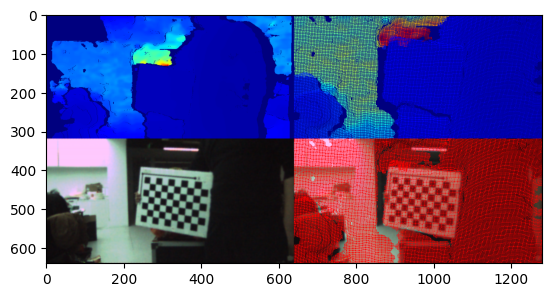

[tianmoucv Datareader FULL] static_1_0@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 76
[tianmoucv Datareader] static_1_0@data/yugu ..., --- containing [RGB,NxTSD] sample: 76  packs


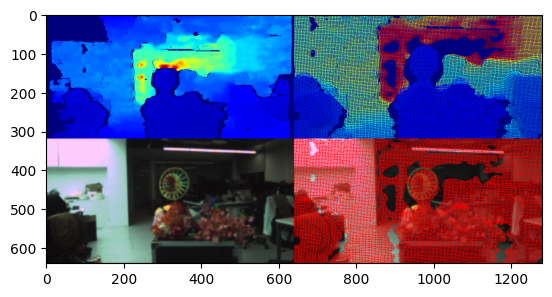

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 18961185
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_1@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 81
[tianmoucv Datareader] static_1_1@data/yugu ..., --- containing [RGB,NxTSD] sample: 81  packs


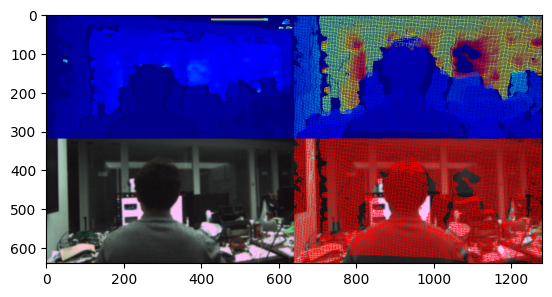

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 22659783
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_2@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 48
[tianmoucv Datareader] static_1_2@data/yugu ..., --- containing [RGB,NxTSD] sample: 48  packs


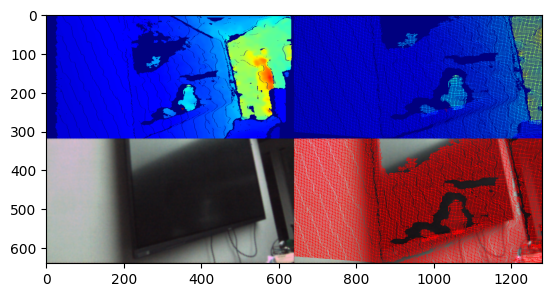

[tianmoucv Datareader FULL] static_1_3@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 37
[tianmoucv Datareader] static_1_3@data/yugu ..., --- containing [RGB,NxTSD] sample: 37  packs


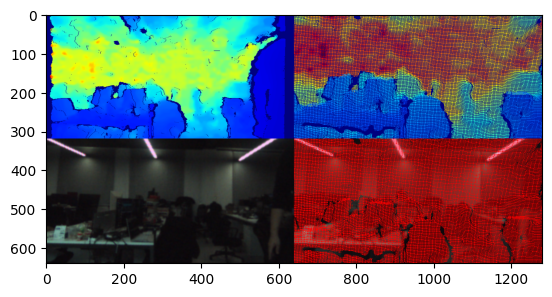

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 29298963
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_4@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 43
[tianmoucv Datareader] static_1_4@data/yugu ..., --- containing [RGB,NxTSD] sample: 43  packs


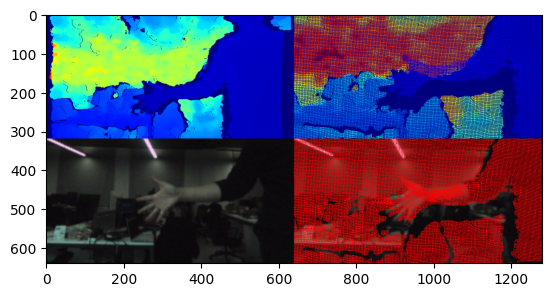

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 34000627
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_5@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 45
[tianmoucv Datareader] static_1_5@data/yugu ..., --- containing [RGB,NxTSD] sample: 45  packs


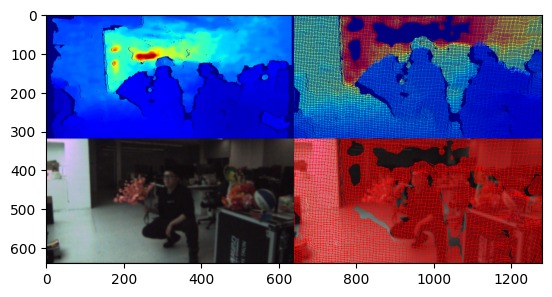

done


In [ ]:
dataPath = ['/data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation']
!ls          /data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation
key_list = []
key_list.append('static_1')
key_list.append('static_1_0')
key_list.append('static_1_1')
key_list.append('static_1_2')
key_list.append('static_1_3')
key_list.append('static_1_4')
key_list.append('static_1_5')

for key in key_list:
    # 数据所在路径
    dataPath_key   = os.path.join(dataPath[0],  key)
    dataPath_depth = os.path.join(dataPath_key, 'depth_raw_aligned')
    # 数据保存路径
    dataPath_save = os.path.join(dataPath_key, 'depth_mapping_to_tmc')
    if not os.path.exists(dataPath_save): os.makedirs(dataPath_save, exist_ok = True) # 新建目录
            
    for file_name in os.listdir(dataPath_depth):
        if file_name.endswith(".npy"): # 仅处理.npy文件
            # 读取
            file_path = os.path.join(dataPath_depth, file_name) # 拼接完整文件路径
            depth_raw = np.load(file_path).astype(float) # 读取npy文件
            # 映射
            aligned_depth = map_depth_to_regular(depth_raw, K_reg, K_rgbd, T_rgbd2reg)
            # 保存
            save_path = os.path.join(dataPath_save, file_name)
            np.save(save_path, aligned_depth)

    # 读tmc数据
    dataPath_tmc = os.path.join(dataPath[0], 'tianmou_data')
    dataset_list = TianmoucDataReader(dataPath_tmc, N = 1, matchkey = key, camera_idx = 0, strict=False)
    index_COP = len(dataset_list) - 1
    sample  = dataset_list[index_COP]
    rgb     = sample['F0']
    rgb     = torch.flip(rgb, [1])        # 镜像翻转
    rgb     = (rgb * 255).to(torch.uint8) # 转换为255
    rgb_out = cv2.UMat(rgb.numpy())       # 注意，带out的图片用于添加文字，且数据类型为uint8

    # 可视化
    viz_depth_raw     = visualize_depth(depth_raw)[20:340, :, :]
    viz_depth_aligned = visualize_depth(aligned_depth)
    viz_rgb_COP       = rgb_out.get()
    viz_overlay       = rgb_out.get()
    viz_overlay[aligned_depth < 10000, :] = [255, 0, 0]
    result_cat1 = cv2.hconcat([viz_depth_raw, viz_depth_aligned])
    result_cat2 = cv2.hconcat([viz_rgb_COP,   viz_overlay])
    result_look = cv2.vconcat([result_cat1,   result_cat2])
    plt.imshow(result_look)
    plt.show()

print('done')

# 数据读取方法

static_1    static_1_1	static_1_3  static_1_5
static_1_0  static_1_2	static_1_4  tianmou_data
[tianmoucv Datareader FULL] static_1@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 75
[tianmoucv Datareader] static_1@data/yuguo/ ..., --- containing [RGB,NxTSD] sample: 75  packs


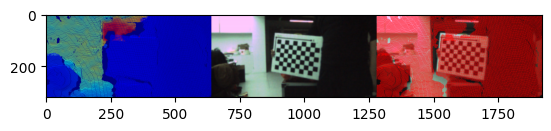

[tianmoucv Datareader FULL] static_1_0@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 76
[tianmoucv Datareader] static_1_0@data/yugu ..., --- containing [RGB,NxTSD] sample: 76  packs


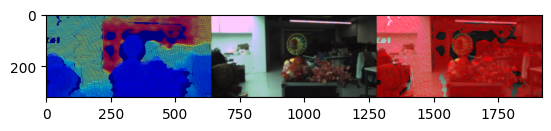

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 18961185
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_1@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 81
[tianmoucv Datareader] static_1_1@data/yugu ..., --- containing [RGB,NxTSD] sample: 81  packs


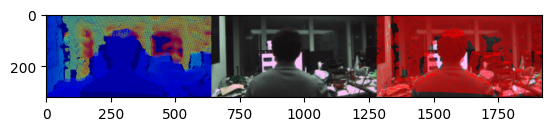

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 22659783
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_2@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 48
[tianmoucv Datareader] static_1_2@data/yugu ..., --- containing [RGB,NxTSD] sample: 48  packs


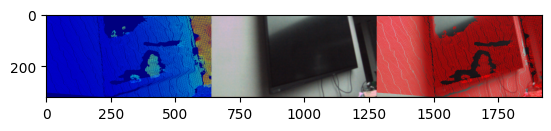

[tianmoucv Datareader FULL] static_1_3@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 37
[tianmoucv Datareader] static_1_3@data/yugu ..., --- containing [RGB,NxTSD] sample: 37  packs


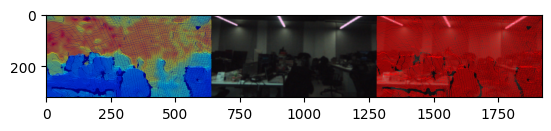

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 29298963
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_4@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 43
[tianmoucv Datareader] static_1_4@data/yugu ..., --- containing [RGB,NxTSD] sample: 43  packs


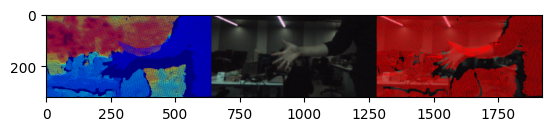

[tianmoucv Datareader Warning]Recoreded Rod: 0  expected: 25  in cone id: 34000627
[tianmoucv Datareader Warning]if you wish to read all data neglecting data loss, set strict=False for datareader
[tianmoucv Datareader FULL] static_1_5@data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation/tianmou_data extracted length: 45
[tianmoucv Datareader] static_1_5@data/yugu ..., --- containing [RGB,NxTSD] sample: 45  packs


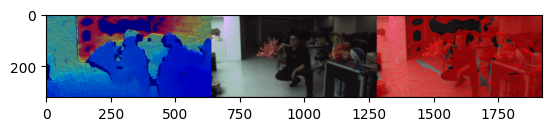

done


In [ ]:
dataPath = ['/data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation']
!ls          /data/yuguo/dataset/dataset_Yihan_TianmouCV/dataset_20251222_depth_evaluation
key_list = []
key_list.append('static_1')
key_list.append('static_1_0')
key_list.append('static_1_1')
key_list.append('static_1_2')
key_list.append('static_1_3')
key_list.append('static_1_4')
key_list.append('static_1_5')

for key in key_list:
    # 数据所在路径
    dataPath_key   = os.path.join(dataPath[0],  key)
    dataPath_depth = os.path.join(dataPath_key, 'depth_mapping_to_tmc')
        
    for file_name in os.listdir(dataPath_depth):
        if file_name.endswith(".npy"): # 仅处理.npy文件
            # 读取
            file_path = os.path.join(dataPath_depth, file_name) # 拼接完整文件路径
            aligned_depth = np.load(file_path).astype(float) # 读取npy文件
            break # 只随便读一个数据就行

    # 读tmc数据
    dataPath_tmc = os.path.join(dataPath[0], 'tianmou_data')
    dataset_list = TianmoucDataReader(dataPath_tmc, N = 1, matchkey = key, camera_idx = 0, strict=False)
    index_COP = int(len(dataset_list) / 2)
    sample  = dataset_list[index_COP]
    rgb     = sample['F0']
    rgb     = torch.flip(rgb, [1])        # 镜像翻转
    rgb     = (rgb * 255).to(torch.uint8) # 转换为255
    rgb_out = cv2.UMat(rgb.numpy())       # 注意，带out的图片用于添加文字，且数据类型为uint8

    # 可视化
    viz_depth_aligned = visualize_depth(aligned_depth)
    viz_rgb_COP       = rgb_out.get()
    viz_overlay       = rgb_out.get()
    viz_overlay[aligned_depth < 10000, :] = [255, 0, 0]
    result_look = cv2.hconcat([viz_depth_aligned, viz_rgb_COP, viz_overlay])
    plt.imshow(result_look)
    plt.show()

print('done')